# Privacy-Preserving EEG Classification with Fuzzy Unlearning

This notebook presents an end-to-end EEG subject-level unlearning pipeline using a public EEG dataset from Kaggle. It compares baseline training, exact retraining after subject removal, and fuzzy unlearning through similarity-based sample weighting.


## Dataset source

This notebook uses the public Complete EEG dataset hosted on Kaggle.

Source:
Aman Anand, Complete EEG dataset, Kaggle
https://www.kaggle.com/datasets/amananandrai/complete-eeg-dataset


This section defines the local dataset path and imports the libraries used for preprocessing, feature extraction, model training, and evaluation.


In [1]:
# Imports for data preprocessing, feature extraction, and ML


from pathlib import Path
DATA_DIR = Path("data/raw")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.neighbors import NearestNeighbors


## 2. Inspect one sample file

This section loads one sample EEG file to verify the file structure, assign the 19 channel names, and estimate the sampling rate from the 60 second recording.


In [2]:

channel_names = [
    "Fp1", "Fp2", "F3", "F4", "F7", "F8",
    "T3", "T4", "C3", "C4", "T5", "T6",
    "P3", "P4", "O1", "O2", "Fz", "Cz", "Pz"
]

csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise RuntimeError("No CSV files found in ../data/raw/. Check the folder path.")

sample_file = csv_files[0]
print("Sample file for inspection:", sample_file.name)

sample_df = pd.read_csv(sample_file, header=None)
sample_df = sample_df.iloc[:, :19]
sample_df.columns = channel_names

print("Sample data shape:", sample_df.shape)
print("Columns in sample:", sample_df.columns.tolist())

n_rows = sample_df.shape[0]
estimated_fs = n_rows / 60.0
print("Estimated sampling rate:", estimated_fs)

Sample file for inspection: s00.csv
Sample data shape: (31000, 19)
Columns in sample: ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'C4', 'T5', 'T6', 'P3', 'P4', 'O1', 'O2', 'Fz', 'Cz', 'Pz']
Estimated sampling rate: 516.6666666666666


In [3]:
# Define the EEG frequency bands and the sliding window configuration used for feature extraction.
# Set sampling rate (update this manually after checking fs from earlier)
fs = int(round(estimated_fs))

# Window and step sizes in seconds
win_len_sec = 2.0
step_sec = 1.5

# Convert durations to number of samples
win_len_samples = int(win_len_sec * fs)
step_samples = int(step_sec * fs)

print("Using sampling rate (fs):", fs)
print("Window size in samples:", win_len_samples)
print("Step size in samples:", step_samples)

# EEG band ranges to calculate power for
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45)
}

# Bandpower Function
# Calculates band power using Welch's method
# Note: Might revisit later if we decide to use multitaper or something more robust.

def bandpower(signal, fs, band_range, nperseg=None):
    low, high = band_range

    if nperseg is None:
        # Conservative default: cap nperseg to 256 or length of signal
        nperseg = min(256, len(signal))

    freqs, psd = welch(signal, fs=fs, nperseg=nperseg)

    # Logical mask for frequency band
    idx_band = np.logical_and(freqs >= low, freqs <= high)

    # Integrate the power spectral density over the band
    return np.trapz(psd[idx_band], freqs[idx_band])


Using sampling rate (fs): 517
Window size in samples: 1034
Step size in samples: 775


In [4]:
# Define helper functions to extract statistical and spectral EEG features from each sliding window.
# These features represent each subject segment in a form suitable for classification.

def extract_window_features(eeg_matrix, subj_id, channel_names, bands, fs, win_len_samples, step_samples):
    feature_rows = []
    subject_ids = []

    total_rows = eeg_matrix.shape[0]

    for start in range(0, total_rows - win_len_samples + 1, step_samples):
        end = start + win_len_samples
        window_data = eeg_matrix[start:end, :]

        feature_dict = {}

        for ch_i, ch_name in enumerate(channel_names):
            signal = window_data[:, ch_i]

            feature_dict[f"{ch_name}_mean"] = np.mean(signal)
            feature_dict[f"{ch_name}_std"] = np.std(signal)
            feature_dict[f"{ch_name}_var"] = np.var(signal)
            feature_dict[f"{ch_name}_min"] = np.min(signal)
            feature_dict[f"{ch_name}_max"] = np.max(signal)

            for band_name, band_range in bands.items():
                feature_dict[f"{ch_name}_bp_{band_name}"] = bandpower(signal, fs, band_range)

        feature_rows.append(feature_dict)
        subject_ids.append(subj_id)

    return feature_rows, subject_ids


## 3. Build retain and forget datasets

In this section, features are extracted from all subject files. Subject 14 is used as the target to forget, while all remaining subjects form the retain set.


In [5]:
# Build the full machine learning dataset from all subject files.
# Subject 14 is used as the target to forget, while all other subjects form the retain set.

retain_train_rows = []
retain_train_labels = []

retain_test_rows = []
retain_test_labels = []

forget_train_rows = []
forget_train_labels = []

forget_test_rows = []
forget_test_labels = []

subject_to_forget = 14
train_ratio = 0.8

train_step_samples = step_samples
test_step_samples = win_len_samples

for filepath in sorted(DATA_DIR.glob("s*.csv")):
    df = pd.read_csv(filepath, header=None)
    df = df.iloc[:, :19]
    df.columns = channel_names

    subj_id = int(filepath.stem[1:3])
    eeg_matrix = df.to_numpy()

    total_rows = eeg_matrix.shape[0]
    split_idx = int(total_rows * train_ratio)

    eeg_train = eeg_matrix[:split_idx, :]
    eeg_test = eeg_matrix[split_idx:, :]

    print(f"{filepath.name} -> total: {total_rows}, train: {eeg_train.shape[0]}, test: {eeg_test.shape[0]}")

    train_rows, train_labels = extract_window_features(
        eeg_train, subj_id, channel_names, bands, fs, win_len_samples, train_step_samples
    )

    test_rows, test_labels = extract_window_features(
        eeg_test, subj_id, channel_names, bands, fs, win_len_samples, test_step_samples
    )

    if subj_id == subject_to_forget:
        forget_train_rows.extend(train_rows)
        forget_train_labels.extend(train_labels)
        forget_test_rows.extend(test_rows)
        forget_test_labels.extend(test_labels)
    else:
        retain_train_rows.extend(train_rows)
        retain_train_labels.extend(train_labels)
        retain_test_rows.extend(test_rows)
        retain_test_labels.extend(test_labels)

feature_columns = pd.DataFrame(retain_train_rows).columns

X_retain_train_raw = pd.DataFrame(retain_train_rows).values
y_retain_train = np.array(retain_train_labels, dtype=int)

X_retain_test_raw = pd.DataFrame(retain_test_rows).values
y_retain_test = np.array(retain_test_labels, dtype=int)

X_forget_train_raw = pd.DataFrame(forget_train_rows).values
y_forget_train = np.array(forget_train_labels, dtype=int)

X_forget_test_raw = pd.DataFrame(forget_test_rows).values
y_forget_test = np.array(forget_test_labels, dtype=int)

print("X_retain_train_raw:", X_retain_train_raw.shape)
print("X_retain_test_raw:", X_retain_test_raw.shape)
print("X_forget_train_raw:", X_forget_train_raw.shape)
print("X_forget_test_raw:", X_forget_test_raw.shape)
print("Number of extracted features:", len(feature_columns))

s00.csv -> total: 31000, train: 24800, test: 6200
s01.csv -> total: 31000, train: 24800, test: 6200
s02.csv -> total: 31000, train: 24800, test: 6200
s03.csv -> total: 31000, train: 24800, test: 6200
s04.csv -> total: 31000, train: 24800, test: 6200
s05.csv -> total: 31000, train: 24800, test: 6200
s06.csv -> total: 31000, train: 24800, test: 6200
s07.csv -> total: 31000, train: 24800, test: 6200
s08.csv -> total: 31000, train: 24800, test: 6200
s09.csv -> total: 31000, train: 24800, test: 6200
s10.csv -> total: 31000, train: 24800, test: 6200
s11.csv -> total: 31000, train: 24800, test: 6200
s12.csv -> total: 31000, train: 24800, test: 6200
s13.csv -> total: 31000, train: 24800, test: 6200
s14.csv -> total: 31000, train: 24800, test: 6200
s15.csv -> total: 31000, train: 24800, test: 6200
s16.csv -> total: 31000, train: 24800, test: 6200
s17.csv -> total: 31000, train: 24800, test: 6200
s18.csv -> total: 31000, train: 24800, test: 6200
s19.csv -> total: 31000, train: 24800, test: 6200


## 4. Baseline model

This section trains the baseline classifier on all subjects, including the target subject to forget. It provides the reference point before any unlearning is applied.


In [6]:
# Train the baseline identification model on all available subjects, including the subject to forget.
# This model represents the original system before any unlearning is applied.

X_base_train_raw = np.vstack([X_retain_train_raw, X_forget_train_raw])
y_base_train = np.concatenate([y_retain_train, y_forget_train])

scaler_base = StandardScaler()
X_base_train = scaler_base.fit_transform(X_base_train_raw)

X_base_retain_test = scaler_base.transform(X_retain_test_raw)
X_base_forget_test = scaler_base.transform(X_forget_test_raw)

rf_baseline = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_baseline.fit(X_base_train, y_base_train)

print("Baseline model trained.")
print("Baseline train shape:", X_base_train.shape)
print("Baseline OOB score:", rf_baseline.oob_score_)

Baseline model trained.
Baseline train shape: (1116, 190)
Baseline OOB score: 0.9301075268817204


In [7]:
# Baseline evaluation on retained subjects
y_pred_base_retain = rf_baseline.predict(X_base_retain_test)

baseline_retain_acc = accuracy_score(y_retain_test, y_pred_base_retain)
baseline_retain_f1 = f1_score(y_retain_test, y_pred_base_retain, average="macro")

# Baseline evaluation on forgotten subject
y_pred_base_forget = rf_baseline.predict(X_base_forget_test)

baseline_forget_acc = accuracy_score(y_forget_test, y_pred_base_forget)
baseline_pred_as_14_rate = np.mean(y_pred_base_forget == subject_to_forget)

print("=== Baseline Results ===")
print("Retain accuracy:", round(baseline_retain_acc, 4))
print("Retain macro F1:", round(baseline_retain_f1, 4))
print("Forget accuracy:", round(baseline_forget_acc, 4))
print("Predicted-as-14 rate:", round(baseline_pred_as_14_rate, 4))

=== Baseline Results ===
Retain accuracy: 0.8971
Retain macro F1: 0.8712
Forget accuracy: 1.0
Predicted-as-14 rate: 1.0


## 5. Exact unlearning

This section retrains the classifier after removing the forgotten subject from the training data. It serves as the strongest reference for subject-level unlearning.


In [8]:
# Measure the confidence and uncertainty of baseline predictions on the forgotten subject.
# High confidence and low entropy indicate that the model still clearly recognizes the subject.
scaler_unlearn = StandardScaler()

X_retain_train = scaler_unlearn.fit_transform(X_retain_train_raw)
X_retain_test = scaler_unlearn.transform(X_retain_test_raw)

X_forget_train = scaler_unlearn.transform(X_forget_train_raw)
X_forget_test = scaler_unlearn.transform(X_forget_test_raw)

print("Unlearning scaler fitted on retain train only.")
print("X_retain_train shape:", X_retain_train.shape)
print("X_forget_test shape:", X_forget_test.shape)

Unlearning scaler fitted on retain train only.
X_retain_train shape: (1085, 190)
X_forget_test shape: (5, 190)


In [9]:
# Train the exact retraining model using only the retained subjects.
# This is the gold standard for unlearning because the forgotten subject is fully removed from training.
rf_exact = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_exact.fit(X_retain_train, y_retain_train)
print("Exact OOB score:", rf_exact.oob_score_)

y_pred_exact_retain = rf_exact.predict(X_retain_test)
y_pred_exact_forget = rf_exact.predict(X_forget_test)

exact_retain_acc = accuracy_score(y_retain_test, y_pred_exact_retain)
exact_retain_f1 = f1_score(y_retain_test, y_pred_exact_retain, average="macro")

print("=== Exact Retraining Results ===")
print("Retain accuracy:", round(exact_retain_acc, 4))
print("Retain macro F1:", round(exact_retain_f1, 4))

vals_exact, cnts_exact = np.unique(y_pred_exact_forget, return_counts=True)
print("Predictions on forget test:", dict(zip(vals_exact, cnts_exact)))

Exact OOB score: 0.9382488479262673
=== Exact Retraining Results ===
Retain accuracy: 0.9029
Retain macro F1: 0.8998
Predictions on forget test: {22: 3, 25: 2}


In [10]:
# Evaluate how uncertain the exact retraining model is on forgotten-subject samples.
# Low confidence and higher entropy suggest that the model no longer strongly identifies subject 14.

k = min(20, len(X_forget_train))

nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(X_forget_train)

dist_k, _ = nn.kneighbors(X_retain_train)

d = dist_k.mean(axis=1)

sigma = np.median(d) + 1e-12

w = 1.0 - np.exp(-(d ** 2) / (2.0 * sigma ** 2))
w = np.clip(w, 0.0, 1.0)

print("=== Fuzzy Weights ===")
print("Shape of w:", w.shape)
print("Min weight:", round(w.min(), 4))
print("Max weight:", round(w.max(), 4))
print("Mean weight:", round(w.mean(), 4))

=== Fuzzy Weights ===
Shape of w: (1085,)
Min weight: 0.2501
Max weight: 1.0
Mean weight: 0.4309


## 6. Fuzzy unlearning

This section applies similarity-based sample weighting to reduce the influence of retained training samples that are most similar to the forgotten subject.


In [11]:
# Train the fuzzy unlearning model on retained subjects only, while weighting samples based on
# their similarity to the forgotten subject. Samples closer to the forgotten subject receive less influence.

rf_fuzzy = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_fuzzy.fit(X_retain_train, y_retain_train, sample_weight=w)
print("Fuzzy OOB score:", rf_fuzzy.oob_score_)

y_pred_fuzzy_retain = rf_fuzzy.predict(X_retain_test)
y_pred_fuzzy_forget = rf_fuzzy.predict(X_forget_test)

fuzzy_retain_acc = accuracy_score(y_retain_test, y_pred_fuzzy_retain)
fuzzy_retain_f1 = f1_score(y_retain_test, y_pred_fuzzy_retain, average="macro")

print("=== Fuzzy Retraining Results ===")
print("Retain accuracy:", round(fuzzy_retain_acc, 4))
print("Retain macro F1:", round(fuzzy_retain_f1, 4))

vals_fuzzy, cnts_fuzzy = np.unique(y_pred_fuzzy_forget, return_counts=True)
print("Predictions on forget test:", dict(zip(vals_fuzzy, cnts_fuzzy)))
y_pred_fuzzy_retain = rf_fuzzy.predict(X_retain_test)
y_pred_fuzzy_forget = rf_fuzzy.predict(X_forget_test)

fuzzy_retain_acc = accuracy_score(y_retain_test, y_pred_fuzzy_retain)
fuzzy_retain_f1 = f1_score(y_retain_test, y_pred_fuzzy_retain, average="macro")

print("=== Fuzzy Retraining Results ===")
print("Retain accuracy:", round(fuzzy_retain_acc, 4))
print("Retain macro F1:", round(fuzzy_retain_f1, 4))

vals_fuzzy, cnts_fuzzy = np.unique(y_pred_fuzzy_forget, return_counts=True)
print("Predictions on forget test:", dict(zip(vals_fuzzy, cnts_fuzzy)))

Fuzzy OOB score: 0.8866359447004608
=== Fuzzy Retraining Results ===
Retain accuracy: 0.88
Retain macro F1: 0.8719
Predictions on forget test: {22: 3, 25: 2}
=== Fuzzy Retraining Results ===
Retain accuracy: 0.88
Retain macro F1: 0.8719
Predictions on forget test: {22: 3, 25: 2}


## 7. Evaluation

This section compares the baseline, exact unlearning, and fuzzy unlearning models in terms of retained-subject utility and behavior on forgotten-subject samples.


In [12]:
import numpy as np

# Evaluate the fuzzy unlearning model on forgotten-subject samples.
# This shows whether the approximate unlearning method reduces subject-specific learnability.
agreement_retain = np.mean(y_pred_fuzzy_retain == y_pred_exact_retain)

proba_exact_retain = rf_exact.predict_proba(X_retain_test)
proba_fuzzy_retain = rf_fuzzy.predict_proba(X_retain_test)

assert np.array_equal(rf_exact.classes_, rf_fuzzy.classes_), "Class order mismatch"

mean_prob_diff_retain = np.mean(np.abs(proba_exact_retain - proba_fuzzy_retain))

# Compare fuzzy and exact on forgotten subject test set
agreement_forget = np.mean(y_pred_fuzzy_forget == y_pred_exact_forget)

proba_exact_forget = rf_exact.predict_proba(X_forget_test)
proba_fuzzy_forget = rf_fuzzy.predict_proba(X_forget_test)

mean_prob_diff_forget = np.mean(np.abs(proba_exact_forget - proba_fuzzy_forget))

print("=== Fuzzy vs Exact Comparison ===")
print("Prediction agreement on retain test:", round(agreement_retain, 4))
print("Mean absolute probability difference on retain test:", round(mean_prob_diff_retain, 6))
print("Prediction agreement on forget test:", round(agreement_forget, 4))
print("Mean absolute probability difference on forget test:", round(mean_prob_diff_forget, 6))

=== Fuzzy vs Exact Comparison ===
Prediction agreement on retain test: 0.8914
Mean absolute probability difference on retain test: 0.008499
Prediction agreement on forget test: 1.0
Mean absolute probability difference on forget test: 0.010355


In [13]:

print("=== Train vs Test Comparison ===")

# Baseline
y_pred_base_train = rf_baseline.predict(X_base_train)
baseline_train_acc = accuracy_score(y_base_train, y_pred_base_train)
baseline_train_f1 = f1_score(y_base_train, y_pred_base_train, average="macro")

print("\nBaseline")
print("Train accuracy:", round(baseline_train_acc, 4))
print("Train macro F1:", round(baseline_train_f1, 4))
print("Test retain accuracy:", round(baseline_retain_acc, 4))
print("Test retain macro F1:", round(baseline_retain_f1, 4))

# Exact
y_pred_exact_train = rf_exact.predict(X_retain_train)
exact_train_acc = accuracy_score(y_retain_train, y_pred_exact_train)
exact_train_f1 = f1_score(y_retain_train, y_pred_exact_train, average="macro")

print("\nExact")
print("Train accuracy:", round(exact_train_acc, 4))
print("Train macro F1:", round(exact_train_f1, 4))
print("Test retain accuracy:", round(exact_retain_acc, 4))
print("Test retain macro F1:", round(exact_retain_f1, 4))

# Fuzzy
y_pred_fuzzy_train = rf_fuzzy.predict(X_retain_train)
fuzzy_train_acc = accuracy_score(y_retain_train, y_pred_fuzzy_train)
fuzzy_train_f1 = f1_score(y_retain_train, y_pred_fuzzy_train, average="macro")

print("\nFuzzy")
print("Train accuracy:", round(fuzzy_train_acc, 4))
print("Train macro F1:", round(fuzzy_train_f1, 4))
print("Test retain accuracy:", round(fuzzy_retain_acc, 4))
print("Test retain macro F1:", round(fuzzy_retain_f1, 4))

=== Train vs Test Comparison ===

Baseline
Train accuracy: 0.9919
Train macro F1: 0.9919
Test retain accuracy: 0.8971
Test retain macro F1: 0.8712

Exact
Train accuracy: 0.9899
Train macro F1: 0.9898
Test retain accuracy: 0.9029
Test retain macro F1: 0.8998

Fuzzy
Train accuracy: 0.9751
Train macro F1: 0.9741
Test retain accuracy: 0.88
Test retain macro F1: 0.8719


In [15]:

def entropy_from_proba(proba):
    p = np.clip(proba, 1e-12, 1.0)
    return -np.sum(p * np.log(p), axis=1)

# Baseline probabilities on forget test
proba_base_forget = rf_baseline.predict_proba(X_base_forget_test)

baseline_max_conf_forget = np.mean(np.max(proba_base_forget, axis=1))
baseline_entropy_forget = np.mean(entropy_from_proba(proba_base_forget))

# Exact probabilities on forget test
exact_max_conf_forget = np.mean(np.max(proba_exact_forget, axis=1))
exact_entropy_forget = np.mean(entropy_from_proba(proba_exact_forget))

# Fuzzy probabilities on forget test
fuzzy_max_conf_forget = np.mean(np.max(proba_fuzzy_forget, axis=1))
fuzzy_entropy_forget = np.mean(entropy_from_proba(proba_fuzzy_forget))

print("=== Forget Test Metrics ===")
print("Baseline max confidence on forget test:", round(baseline_max_conf_forget, 4))
print("Baseline entropy on forget test:", round(baseline_entropy_forget, 4))

print("Exact max confidence on forget test:", round(exact_max_conf_forget, 4))
print("Exact entropy on forget test:", round(exact_entropy_forget, 4))

print("Fuzzy max confidence on forget test:", round(fuzzy_max_conf_forget, 4))
print("Fuzzy entropy on forget test:", round(fuzzy_entropy_forget, 4))

=== Forget Test Metrics ===
Baseline max confidence on forget test: 0.3064
Baseline entropy on forget test: 2.9044
Exact max confidence on forget test: 0.1106
Exact entropy on forget test: 3.265
Fuzzy max confidence on forget test: 0.1208
Fuzzy entropy on forget test: 3.2357


In [16]:

print("=== Forget Test Prediction Distribution ===")

vals_base, cnts_base = np.unique(y_pred_base_forget, return_counts=True)
vals_exact, cnts_exact = np.unique(y_pred_exact_forget, return_counts=True)
vals_fuzzy, cnts_fuzzy = np.unique(y_pred_fuzzy_forget, return_counts=True)

print("\nBaseline predictions on forget test:")
print(dict(zip(vals_base, cnts_base)))

print("\nExact retraining predictions on forget test:")
print(dict(zip(vals_exact, cnts_exact)))

print("\nFuzzy retraining predictions on forget test:")
print(dict(zip(vals_fuzzy, cnts_fuzzy)))

=== Forget Test Prediction Distribution ===

Baseline predictions on forget test:
{14: 5}

Exact retraining predictions on forget test:
{22: 3, 25: 2}

Fuzzy retraining predictions on forget test:
{22: 3, 25: 2}


## 8. Results

The results show how the three model settings differ in retained-subject performance and in their confidence and uncertainty on forgotten-subject samples.


In [17]:

print("=== FINAL SUMMARY ===")

print("\nBaseline")
print("Retain accuracy:", round(baseline_retain_acc, 4))
print("Retain macro F1:", round(baseline_retain_f1, 4))
print("Forget accuracy:", round(baseline_forget_acc, 4))
print("Predicted-as-14 rate on forget test:", round(baseline_pred_as_14_rate, 4))
print("Max confidence on forget test:", round(baseline_max_conf_forget, 4))
print("Entropy on forget test:", round(baseline_entropy_forget, 4))

print("\nExact Retraining")
print("Retain accuracy:", round(exact_retain_acc, 4))
print("Retain macro F1:", round(exact_retain_f1, 4))
print("Max confidence on forget test:", round(exact_max_conf_forget, 4))
print("Entropy on forget test:", round(exact_entropy_forget, 4))

print("\nFuzzy Retraining")
print("Retain accuracy:", round(fuzzy_retain_acc, 4))
print("Retain macro F1:", round(fuzzy_retain_f1, 4))
print("Max confidence on forget test:", round(fuzzy_max_conf_forget, 4))
print("Entropy on forget test:", round(fuzzy_entropy_forget, 4))

print("\nFuzzy vs Exact")
print("Prediction agreement on retain test:", round(agreement_retain, 4))
print("Mean absolute probability difference on retain test:", round(mean_prob_diff_retain, 6))
print("Prediction agreement on forget test:", round(agreement_forget, 4))
print("Mean absolute probability difference on forget test:", round(mean_prob_diff_forget, 6))

=== FINAL SUMMARY ===

Baseline
Retain accuracy: 0.8971
Retain macro F1: 0.8712
Forget accuracy: 1.0
Predicted-as-14 rate on forget test: 1.0
Max confidence on forget test: 0.3064
Entropy on forget test: 2.9044

Exact Retraining
Retain accuracy: 0.9029
Retain macro F1: 0.8998
Max confidence on forget test: 0.1106
Entropy on forget test: 3.265

Fuzzy Retraining
Retain accuracy: 0.88
Retain macro F1: 0.8719
Max confidence on forget test: 0.1208
Entropy on forget test: 3.2357

Fuzzy vs Exact
Prediction agreement on retain test: 0.8914
Mean absolute probability difference on retain test: 0.008499
Prediction agreement on forget test: 1.0
Mean absolute probability difference on forget test: 0.010355


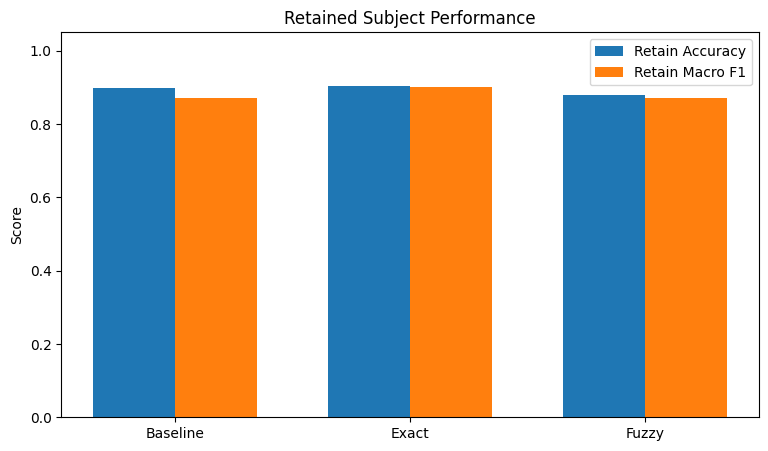

In [18]:

methods = ["Baseline", "Exact", "Fuzzy"]

retain_accs = [baseline_retain_acc, exact_retain_acc, fuzzy_retain_acc]
retain_f1s = [baseline_retain_f1, exact_retain_f1, fuzzy_retain_f1]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, retain_accs, width, label="Retain Accuracy")
plt.bar(x + width/2, retain_f1s, width, label="Retain Macro F1")

plt.xticks(x, methods)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Retained Subject Performance")
plt.legend()
plt.show()

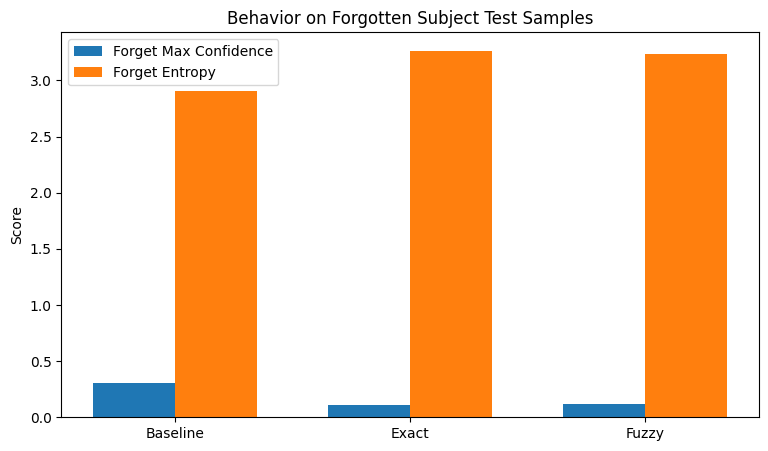

In [19]:

methods = ["Baseline", "Exact", "Fuzzy"]

forget_conf = [baseline_max_conf_forget, exact_max_conf_forget, fuzzy_max_conf_forget]
forget_entropy = [baseline_entropy_forget, exact_entropy_forget, fuzzy_entropy_forget]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, forget_conf, width, label="Forget Max Confidence")
plt.bar(x + width/2, forget_entropy, width, label="Forget Entropy")

plt.xticks(x, methods)
plt.ylabel("Score")
plt.title("Behavior on Forgotten Subject Test Samples")
plt.legend()
plt.show()

In [20]:
# Top baseline feature importances

imp_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_baseline.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Top 15 Baseline Feature Importances ===")
print(imp_df.head(15))

=== Top 15 Baseline Feature Importances ===
          feature  importance
19   Fp2_bp_gamma    0.033746
149   O1_bp_gamma    0.029637
59    F8_bp_gamma    0.024849
9    Fp1_bp_gamma    0.023851
159   O2_bp_gamma    0.020667
49    F7_bp_gamma    0.020019
18    Fp2_bp_beta    0.018533
128    P3_bp_beta    0.018402
79    T4_bp_gamma    0.018377
1         Fp1_std    0.018273
68     T3_bp_beta    0.017941
8     Fp1_bp_beta    0.017925
78     T4_bp_beta    0.017854
119   T6_bp_gamma    0.017468
12        Fp2_var    0.017317


## 9. Final takeaway

The baseline model retains subject-specific information. Exact retraining provides the strongest forgetting behavior. Fuzzy unlearning moves in the same direction while preserving most retained-subject utility, though the limited dataset size and correlated sliding windows remain important limitations.
